# Search Refresh Opportunity Scoring

**Lane:** Refresh / Content Opportunity Scoring  
**Question:** Can observable page signals rank items whose recent search impressions are declining, to help editors prioritize a review queue?

This capstone uses the anonymized starter release bundled with this repository. It is a reproducible portfolio analysis on a 30,000-row teaching slice, not the gated full warehouse. Open in [Google Colab](https://colab.research.google.com/github/Javeria-crypto326/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true).


## 1. Question and decision

The output is a ranked, pseudonymized page review queue. A human editor can inspect high-ranked pages, check whether a refresh is appropriate, and choose a specific action. A false positive spends editorial time; a false negative may delay a useful review. This analysis supports triage and does not prescribe automatic publishing.

In [1]:
# Install only the packages needed by the repository's local starter-data pipeline.
%pip -q install pandas numpy scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import os, subprocess, sys, json

REPO_URL = "https://github.com/Javeria-crypto326/flyrank-ml-internship.git"
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "data/raw/content_refresh_anonymized.csv").exists()), None)
if ROOT is None:
    # Colab opened from GitHub starts in /content; clone this public repo there.
    ROOT = Path("/content/flyrank-ml-internship")
    if not (ROOT / "data/raw/content_refresh_anonymized.csv").exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
os.chdir(ROOT)
os.environ["PYTHONIOENCODING"] = "utf-8"
print("Repository ready:", ROOT.name)


Repository ready: flyrank-ml-internship


## 2. Data

The bundled `content_refresh_anonymized.csv` has one row per pseudonymized content item (30,000 rows, 44 columns; 32 pseudonymized clients). Metrics are a trailing 90-day snapshot with recent and prior 30-day comparison fields; the bundled slice does not state calendar start/end dates. No warehouse tables or Hugging Face data were queried. Client and content IDs are used only to group the split and align baseline scores, never as model features. Titles, URLs, domains, raw queries, and client names are not present in this public-safe slice. Provider/model fields and target-derived trend fields are excluded from predictors.

In [3]:
import pandas as pd
raw = pd.read_csv(ROOT / "data/raw/content_refresh_anonymized.csv")
print(f"Rows: {len(raw):,}; columns: {raw.shape[1]}; clients (grouping only): {raw.client_id.nunique()}")
print(f"Decline-proxy rate: {(raw.trend_direction == 'down').mean():.3f}")
assert len(raw) == 30_000


Rows: 30,000; columns: 44; clients (grouping only): 32
Decline-proxy rate: 0.542


## 3. Methodology and validation

**Label:** `is_declining_label = 1` when the slice's `trend_direction` is `down`, which is derived from the comparison of recent and prior 30-day impressions. It describes an observed directional proxy, not a future outcome. **Leakage controls:** omit `trend_pct`, `trend_direction`, `client_id`, and `content_id` from the feature matrix; train/test clients do not overlap. Because predictors and label are built from overlapping snapshot windows, this is a contemporaneous classification/ranking exercise and cannot establish future forecasting skill.

**Baseline:** transparent weighted score (40% visibility, 30% freshness risk, 25% position opportunity, 5% content-depth gap). **Models:** logistic regression, depth-limited decision tree, and random forest; one-hot categorical encoding and numeric features from `scripts/ml_utils.py`. **Split:** deterministic 80/20 client holdout (seed 42), with the same test rows and target for every model and baseline. The model is selected by Precision@50. Metrics measure rank discrimination against this proxy; they do not measure the effect of making edits.

In [4]:
# Rebuild features, rule baseline, client-held-out model comparison, and public-safe charts.
# Use the repo's repeatable reference pipeline stages 1?4; stage 5 only creates an optional PDF.
for script in ["01_prepare_features.py", "02_baseline_score.py", "03_train_model.py", "04_evaluate_and_export.py"]:
    subprocess.run([sys.executable, str(ROOT / "scripts" / script)], cwd=ROOT, check=True)
results = json.loads((ROOT / "outputs/model_results.json").read_text(encoding="utf-8"))
preds = pd.read_csv(ROOT / "data/processed/model_predictions.csv")
test = preds[preds["split"] == "test"]
assert set(preds.loc[preds.split == "train", "client_id"]).isdisjoint(set(test.client_id))
print("Split:", results["split_strategy"], "| train:", results["train_rows"], "| test:", results["test_rows"])
print("Holdout base rate:", round(test.is_declining_label.mean(), 3))
print("Leakage fields in features:", set(["trend_pct", "trend_direction", "client_id", "content_id"]) & set(results["model_numeric_features"] + results["model_categorical_features"]))


Split: client_holdout | train: 27675 | test: 2325
Holdout base rate: 0.391
Leakage fields in features: set()


## 4. Results: models vs baseline

The comparison below is computed on the same held-out client groups. Precision@50 is the share of decline-proxy positives among the 50 highest-scored held-out rows; compare it with the holdout base rate. ROC AUC and average precision summarize discrimination across thresholds.

In [5]:
comparison = pd.DataFrame([
    {"Method": name, "ROC AUC": m["roc_auc"], "Average precision": m["average_precision"], "Precision@50": m["precision_at_50"]}
    for name, m in results["models"].items()
] + [{"Method": "transparent baseline", "ROC AUC": results["baseline"]["baseline_roc_auc"],
      "Average precision": results["baseline"]["baseline_average_precision"], "Precision@50": results["baseline"]["baseline_precision_at_50"]}])
comparison.sort_values("Precision@50", ascending=False).round(3)


,Method,ROC AUC,Average precision,Precision@50
2,random_forest,0.750,0.618,0.74
0,decision_tree,0.742,0.575,0.62
1,logistic_regression,0.700,0.522,0.40
3,transparent baseline,0.627,0.468,0.24


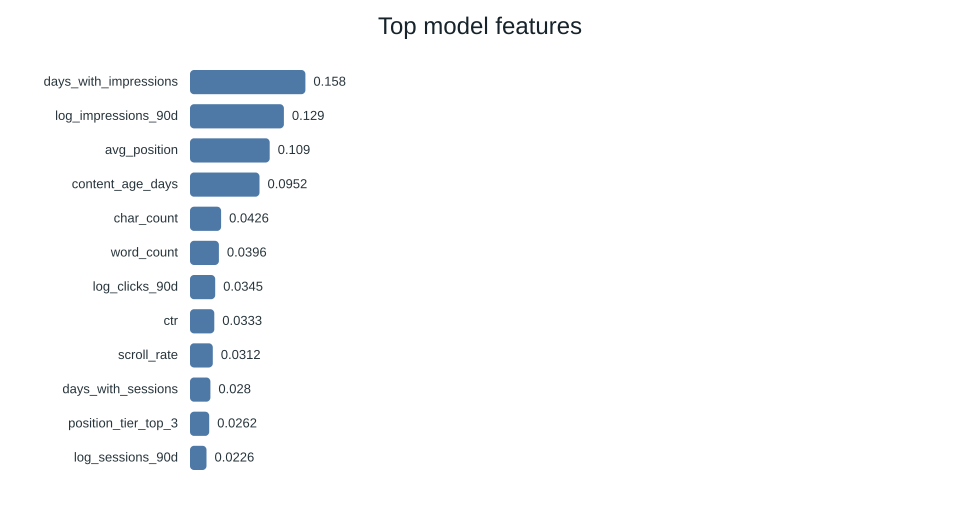

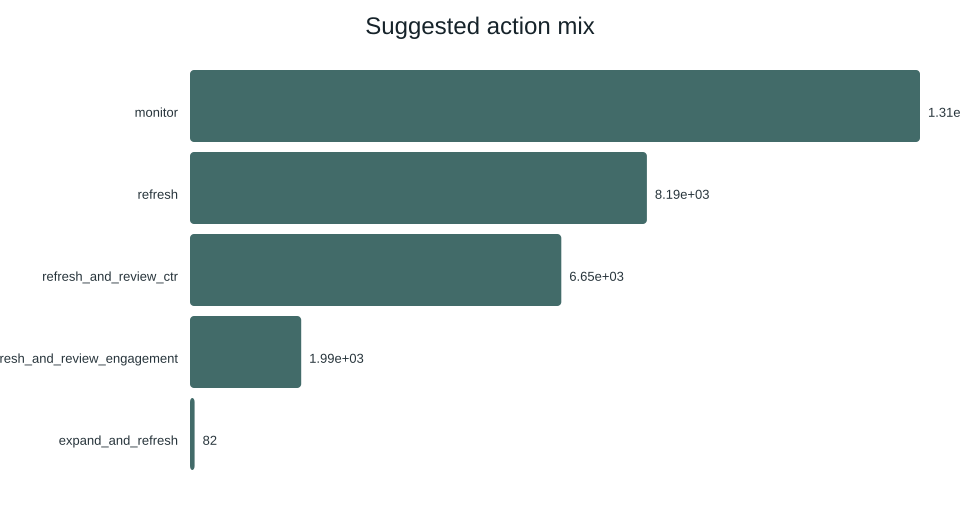

In [6]:
from IPython.display import display, SVG
for chart in ["top_feature_importance.svg", "action_mix.svg"]:
    display(SVG(filename=str(ROOT / "outputs/charts" / chart)))


## 5. Limitations and honest framing

This is a bundled teaching slice, not the full warehouse release, and its metrics may not transfer to other populations or later periods. The label is a rule-derived, same-snapshot decline proxy; overlapping 90-day features can encode information related to the label. A client holdout tests transfer to unseen pseudonymized clients within this slice, but it is not a temporal holdout. Feature importance is model-specific association, not causal evidence. The model does not prove ranking-system behavior or that a refresh causes more clicks. Treat every score as directional decision support and verify page context before action.

## 6. Ranked recommendations

1. **Review the top-ranked items first** when the model flags a decline proxy and the rule baseline also detects visible opportunity; confirm demand, data quality, and business context manually.
2. **Use reason codes to choose the review**, such as a CTR/metadata check for visible low-CTR pages, a content-depth review for thin visible pages, or a freshness check for stale pages.
3. **Keep a monitor queue** for lower-scored items and revisit after new measurement windows are available.
4. **Do not auto-publish changes.** Record the editor's decision and evaluate future outcomes with a genuinely later, non-overlapping time window before claiming forecast or refresh impact.

In [7]:
queue = pd.read_csv(ROOT / "outputs/refresh_queue.csv")
print("Action counts in the full scored queue (no IDs or row-level records):")
display(queue["suggested_action"].value_counts().rename_axis("recommended action").to_frame("pages").reset_index())
print("Reason-code counts (top 8):")
reasons = queue["final_reason_codes"].fillna("").str.split("|").explode()
display(reasons[reasons.ne("")].value_counts().head(8).rename_axis("reason code").to_frame("pages").reset_index())


Action counts in the full scored queue (no IDs or row-level records):


,recommended action,pages
0,monitor,13083
1,refresh,8188
2,refresh_and_review_ctr,6654
3,refresh_and_review_engagement,1993
4,expand_and_refresh,82


Reason-code counts (top 8):


,reason code,pages
0,declining_with_demand,13152
1,visible_model_opportunity,10650
2,low_ctr_visible_page,9759
3,ctr_review_candidate,9759
4,general_refresh_review,9117
5,model_decline_risk,8427
6,page_one_decay_risk,7076
7,low_engagement_visible_page,6508


## 7. Paper artifacts

The corresponding public paper is [`docs/index.html`](../../docs/index.html). The metrics and charts below are regenerated from the local starter dataset and repository scripts. The ranked queue is generated locally; raw rows and pseudonymous identifiers are not included in the paper.

In [8]:
print("Paper:", (ROOT / "docs/index.html").resolve())
print("Charts:", *sorted(p.name for p in (ROOT / "outputs/charts").glob("*.svg")), sep="\n- ")


Paper: D:\flyrank-ml-internship\docs\index.html
Charts:
- action_mix.svg
- confidence_mix.svg
- top_feature_importance.svg
- top_reason_codes.svg
- trend_distribution.svg


## Reproducibility

From a fresh clone, install `requirements.txt`, then run the first four stages in order:

```bash
python scripts/01_prepare_features.py
python scripts/02_baseline_score.py
python scripts/03_train_model.py
python scripts/04_evaluate_and_export.py
```

Random seed: 42. The data used is the bundled starter CSV. The pipeline keeps processed rows under the ignored `data/processed/` path. The paper and charts are in `docs/` and `outputs/charts/`.

### Demo outline (5 minutes)
1. State the editorial triage question and the cost of a wrong priority.
2. Show the public-safe 30,000-row starter dataset and explain the decline proxy.
3. Walk through the client-held-out split, baseline and leakage exclusions.
4. Compare Precision@50, ROC AUC, and average precision; explain the snapshot-overlap limitation.
5. Show reason-coded queue actions and close with a human-review recommendation.

### Social post
Built a reproducible content refresh review scorer on FlyRank's anonymized internship starter data. A client-held-out random forest ranked the decline proxy above a transparent baseline in this snapshot; the result is directional triage evidence, not a future forecast or causal refresh claim.

### Employer summary
I built an end-to-end, reproducible content review ranking workflow using pseudonymized search and engagement aggregates. I compared interpretable rules with three classifiers under client-held-out validation and documented leakage and measurement limits. The output is a reason-coded editorial queue designed for human review, with public-safe reporting and reproducibility instructions.

## Acknowledgments

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

## Self-check

- [x] Question, data, methodology, results, limitations, ranked recommendations, reproducibility, and credit are documented.
- [x] IDs and target-derived trend fields are excluded from predictors; client groups do not cross the validation split.
- [x] Notebook cells regenerate the evaluated metrics and charts.
- [x] No client names, domains, page URLs, queries, credentials, or row-level queue records are published.

Run all cells top to bottom in Colab after opening from the repository. Save the resulting notebook back to your repo when you want the executed outputs committed.